# Nelson-Siegel-Svensson (NSS) — Tasas forward desde cero

**Modelo de estructura temporal de tasas de interés con dos componentes de curvatura**

---

## 1. Contexto histórico: ¿Por qué abandonar la parsimonia de Nelson-Siegel?

### El origen: Nelson & Siegel (1987)

En 1987, Charles R. Nelson y Andrew F. Siegel publicaron *"Parsimonious Modeling of Yield Curves"* en el *Journal of Business*. Su propuesta era radical en su simplicidad: modelar toda la curva de tasas forward con **solo cuatro parámetros** ($\beta_0, \beta_1, \beta_2, \tau$).

La ecuación de la tasa forward instantánea es:

$$f(m; \boldsymbol{\beta}, \tau) = \beta_0 + \beta_1 e^{-m/\tau} + \beta_2 \frac{m}{\tau} e^{-m/\tau}$$

La belleza del modelo radica en la **interpretación económica directa** de sus componentes:

| Componente | Forma | Efecto | Interpretación |
|---|---|---|---|
| $\beta_0$ | Constante | Largo plazo | Nivel de la curva ($m \to \infty$) |
| $\beta_1 e^{-m/\tau}$ | Decreciente monótona | Corto plazo | Pendiente (diferencia largo-corto) |
| $\beta_2 \frac{m}{\tau} e^{-m/\tau}$ | Joroba (hump) | Mediano plazo | Curvatura |

El parámetro $\tau$ controla la **velocidad de decaimiento** y la posición del máximo de la joroba.

### El problema: una sola joroba no basta

A pesar de su elegancia, el modelo NS tiene una **limitación estructural seria**: solo puede generar **una única joroba** (o valle). En la práctica, las curvas de tasas en mercados emergentes, o durante períodos de volatilidad extrema, exhiben con frecuencia **dos jorobas** o formas en "S" con múltiples inflexiones.

Algunos contextos específicos donde NS falla:
- **Curvas de Japón post-1990**: tasas ultra-bajas en el corto plazo, repunte en el medio, caída y re-ascenso en el largo plazo.
- **Mercados emergentes con controles de capital**: distorsiones en diferentes segmentos que crean dos husos de curvatura independientes.
- **Períodos de transición de política monetaria**: dos "jorobas" que reflejan expectativas distintas en horizontes corto y largo.
- **Curvas europeas durante la crisis soberana (2010-2012)**: primas de riesgo concentradas en tramos específicos.

### La solución de Svensson (1994): agregar flexibilidad con parsimonia

Lars E. O. Svensson, en el IIES de Estocolmo, publicó en 1994 *"Estimating and Interpreting Forward Interest Rates: Sweden 1992-1994"* (NBER Working Paper 4871). Su extensión es elegante: **añade un cuarto término** idéntico en forma al tercero de NS, pero con su **propio parámetro de decaimiento** $\tau_2$:

$$f(m; \boldsymbol{\beta}, \tau_1, \tau_2) = \beta_0 + \beta_1 e^{-m/\tau_1} + \beta_2 \frac{m}{\tau_1} e^{-m/\tau_1} + \beta_3 \frac{m}{\tau_2} e^{-m/\tau_2}$$

Este cuarto término añade **una segunda joroba** ubicada en $m = \tau_2$, dando al modelo la capacidad de capturar curvas bimodales.

### El debate: parsimonia vs. ajuste

La extensión de Svensson representa un **compromiso deliberado**: pasa de 4 a 6 parámetros ($\beta_0, \beta_1, \beta_2, \beta_3, \tau_1, \tau_2$). Esto implica:

- **Mayor flexibilidad**: puede ajustar formas de curva que NS no puede capturar.
- **Menor parsimonia**: más parámetros = mayor riesgo de sobreajuste y problemas de identificación.
- **Optimización más compleja**: con dos $\tau$, el paisaje de la función de pérdida es no convexo con múltiples mínimos locales.

Hoy el modelo NSS es el **estándar de facto** en bancos centrales. El BIS publicó en 2005 una encuesta mostrando que la mayoría de los bancos centrales del G10 usan NSS o alguna variante para publicar sus curvas de tasas cero oficiales.

---

## 2. El modelo Nelson-Siegel-Svensson en detalle

### 2.1 Tasa forward instantánea

$$\boxed{f(m) = \beta_0 + \beta_1 e^{-m/\tau_1} + \beta_2 \frac{m}{\tau_1} e^{-m/\tau_1} + \beta_3 \frac{m}{\tau_2} e^{-m/\tau_2}}$$

donde $m > 0$ es el plazo en años. Restricciones para comportamiento económico sensato:
- $\beta_0 > 0$: nivel largo plazo positivo
- $\tau_1, \tau_2 > 0$: velocidades de decaimiento positivas
- $\tau_1 \neq \tau_2$: para que los dos términos de curvatura sean linealmente independientes

### 2.2 Tasa spot (rendimiento al vencimiento)

$$y(m) = \frac{1}{m}\int_0^m f(u)\, du = \beta_0 + \beta_1 \frac{1-e^{-m/\tau_1}}{m/\tau_1} + \beta_2 \left[\frac{1-e^{-m/\tau_1}}{m/\tau_1} - e^{-m/\tau_1}\right] + \beta_3 \left[\frac{1-e^{-m/\tau_2}}{m/\tau_2} - e^{-m/\tau_2}\right]$$

### 2.3 Forma matricial (lineal en los betas, no lineal en los taus)

Fijando $\lambda_1 = 1/\tau_1$ y $\lambda_2 = 1/\tau_2$:

$$f(m) = \underbrace{\begin{bmatrix} 1 & e^{-\lambda_1 m} & \lambda_1 m e^{-\lambda_1 m} & \lambda_2 m e^{-\lambda_2 m} \end{bmatrix}}_{\mathbf{x}(m)^\top} \begin{bmatrix} \beta_0 \\ \beta_1 \\ \beta_2 \\ \beta_3 \end{bmatrix}$$

**Estrategia de estimación (profile likelihood / grid search)**:

Para cada par $(\lambda_1, \lambda_2)$ fijo:
$$\hat{\boldsymbol{\beta}}(\lambda_1, \lambda_2) = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{f}$$

Optimizamos sobre $\lambda_1, \lambda_2$ minimizando SSE:
$$\min_{\lambda_1, \lambda_2} \|\mathbf{f} - \mathbf{X}(\lambda_1,\lambda_2)\hat{\boldsymbol{\beta}}(\lambda_1,\lambda_2)\|^2$$

### 2.4 Propiedades del modelo

| Propiedad | Comportamiento |
|---|---|
| $f(0)$ | $\beta_0 + \beta_1$ (tasa instantánea) |
| $f(\infty)$ | $\beta_0$ (tasa largo plazo) |
| Número de parámetros | 6 ($\beta_0,\beta_1,\beta_2,\beta_3,\tau_1,\tau_2$) |
| Máximo 1ª joroba | $m \approx \tau_1$ |
| Máximo 2ª joroba | $m \approx \tau_2$ |

---

## 3. Implementación desde cero

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.optimize import minimize, minimize_scalar

np.random.seed(42)
print('Librerias cargadas.')
print(f'NumPy {np.__version__}')


Librerias cargadas.
NumPy 2.3.5


### 3.1 Datos sintéticos (curva con DOS jorobas — imposible para NS puro)

In [5]:
# Parametros verdaderos
beta0_true, beta1_true = 5.0, -2.5
beta2_true, beta3_true = 4.0, -3.0
tau1_true,  tau2_true  = 1.0,  4.0

# Plazos: de 1 mes a 30 anos
m = np.array([1/12, 3/12, 6/12, 1, 1.5, 2, 3, 5, 7, 10, 15, 20, 25, 30])

def nss_forward(m, beta0, beta1, beta2, beta3, tau1, tau2):
    lam1 = 1 / tau1
    lam2 = 1 / tau2
    return (beta0
            + beta1 * np.exp(-lam1 * m)
            + beta2 * lam1 * m * np.exp(-lam1 * m)
            + beta3 * lam2 * m * np.exp(-lam2 * m))

f_true = nss_forward(m, beta0_true, beta1_true, beta2_true, beta3_true, tau1_true, tau2_true)
y      = f_true + np.random.normal(0, 0.05, len(m))

df_obs = pd.DataFrame({'Plazo (anos)': m, 'Tasa forward (%)': np.round(y, 4)})
print(df_obs.to_string(index=False))


 Plazo (anos)  Tasa forward (%)
     0.083333            2.9702
     0.250000            3.6487
     0.500000            4.3982
     1.000000            5.0439
     1.500000            4.9960
     2.000000            4.8228
     3.000000            4.4891
     5.000000            4.0819
     7.000000            4.0875
    10.000000            4.4132
    15.000000            4.7123
    20.000000            4.8756
    25.000000            4.9759
    30.000000            4.8919


### 3.2 Funciones centrales del modelo NSS

In [6]:
def nss_forward_matrix(m, lam1, lam2):
    """
    Matriz de diseno X para la tasa forward NSS.
    X[i] = [1, exp(-lam1*m), lam1*m*exp(-lam1*m), lam2*m*exp(-lam2*m)]
    """
    m = np.asarray(m, dtype=float)
    col0 = np.ones_like(m)
    col1 = np.exp(-lam1 * m)
    col2 = lam1 * m * np.exp(-lam1 * m)
    col3 = lam2 * m * np.exp(-lam2 * m)
    return np.column_stack([col0, col1, col2, col3])


def nss_spot_matrix(m, lam1, lam2):
    """
    Matriz de diseno X para la tasa spot NSS.
    """
    m   = np.asarray(m, dtype=float)
    eps = 1e-10
    lm1 = lam1 * m + eps
    lm2 = lam2 * m + eps
    col0 = np.ones_like(m)
    col1 = (1 - np.exp(-lm1)) / lm1
    col2 = (1 - np.exp(-lm1)) / lm1 - np.exp(-lm1)
    col3 = (1 - np.exp(-lm2)) / lm2 - np.exp(-lm2)
    return np.column_stack([col0, col1, col2, col3])


def fit_betas(m, y, lam1, lam2, forward=True):
    """Dado (lam1, lam2) fijo, estima betas por minimos cuadrados."""
    X = nss_forward_matrix(m, lam1, lam2) if forward else nss_spot_matrix(m, lam1, lam2)
    beta_hat, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ beta_hat
    sse   = np.sum((y - y_hat)**2)
    return beta_hat, y_hat, sse


def nss_sse(lam_pair, m, y, forward=True):
    """Funcion objetivo: SSE como funcion de (lam1, lam2)."""
    lam1, lam2 = lam_pair
    if lam1 <= 0 or lam2 <= 0 or abs(lam1 - lam2) < 0.01:
        return 1e10
    _, _, sse = fit_betas(m, y, lam1, lam2, forward=forward)
    return sse


print('Funciones NSS definidas:')
print('  nss_forward_matrix -> matriz de diseno forward')
print('  nss_spot_matrix    -> matriz de diseno spot')
print('  fit_betas          -> OLS dado (lam1, lam2)')
print('  nss_sse            -> funcion objetivo')


Funciones NSS definidas:
  nss_forward_matrix -> matriz de diseno forward
  nss_spot_matrix    -> matriz de diseno spot
  fit_betas          -> OLS dado (lam1, lam2)
  nss_sse            -> funcion objetivo


### 3.3 Estimación por grid search + optimización local

In [7]:
# Grid search para punto inicial
lam_grid = np.linspace(0.1, 3.0, 25)
best_sse, best_pair = np.inf, (1.0, 0.5)

print('Grid search en (lam1, lam2)...')
for l1 in lam_grid:
    for l2 in lam_grid:
        if abs(l1 - l2) < 0.1:
            continue
        try:
            sse = nss_sse([l1, l2], m, y)
            if sse < best_sse:
                best_sse, best_pair = sse, (l1, l2)
        except Exception:
            continue

print(f'Mejor punto inicial: lam1={best_pair[0]:.3f}, lam2={best_pair[1]:.3f}, SSE={best_sse:.6f}')

# Refinamiento con Nelder-Mead
result = minimize(
    nss_sse, x0=list(best_pair), args=(m, y, True),
    method='Nelder-Mead',
    options={'xatol': 1e-8, 'fatol': 1e-10, 'maxiter': 50000}
)
lam1_opt, lam2_opt = result.x
tau1_opt, tau2_opt = 1/lam1_opt, 1/lam2_opt
beta_opt, y_hat, sse_opt = fit_betas(m, y, lam1_opt, lam2_opt)
beta0_opt, beta1_opt, beta2_opt, beta3_opt = beta_opt

print()
print('='*55)
print('  PARAMETROS NSS ESTIMADOS (tasas forward)')
print('='*55)
print(f'  beta0 = {beta0_opt:8.4f}   (nivel largo plazo)')
print(f'  beta1 = {beta1_opt:8.4f}   (pendiente)')
print(f'  beta2 = {beta2_opt:8.4f}   (1a curvatura)')
print(f'  beta3 = {beta3_opt:8.4f}   (2a curvatura)')
print(f'  tau1  = {tau1_opt:8.4f}   (posicion 1a joroba)')
print(f'  tau2  = {tau2_opt:8.4f}   (posicion 2a joroba)')
print(f'  lam1  = {lam1_opt:8.4f}   (= 1/tau1)')
print(f'  lam2  = {lam2_opt:8.4f}   (= 1/tau2)')
print(f'  SSE   = {sse_opt:.6f}')
print('='*55)

params_comp = pd.DataFrame({
    'Parametro': ['beta0','beta1','beta2','beta3','tau1','tau2'],
    'Verdadero': [beta0_true, beta1_true, beta2_true, beta3_true, tau1_true, tau2_true],
    'Estimado' : [beta0_opt,  beta1_opt,  beta2_opt,  beta3_opt,  tau1_opt,  tau2_opt]
})
params_comp['Error'] = (params_comp['Estimado'] - params_comp['Verdadero']).round(4)
print(params_comp.to_string(index=False))


Grid search en (lam1, lam2)...
Mejor punto inicial: lam1=1.067, lam2=0.221, SSE=0.023337

  PARAMETROS NSS ESTIMADOS (tasas forward)
  beta0 =   4.9576   (nivel largo plazo)
  beta1 =  -2.4470   (pendiente)
  beta2 =   4.0410   (1a curvatura)
  beta3 =  -2.8117   (2a curvatura)
  tau1  =   0.9967   (posicion 1a joroba)
  tau2  =   3.9577   (posicion 2a joroba)
  lam1  =   1.0033   (= 1/tau1)
  lam2  =   0.2527   (= 1/tau2)
  SSE   = 0.017163
Parametro  Verdadero  Estimado   Error
    beta0        5.0  4.957642 -0.0424
    beta1       -2.5 -2.447001  0.0530
    beta2        4.0  4.040973  0.0410
    beta3       -3.0 -2.811668  0.1883
     tau1        1.0  0.996662 -0.0033
     tau2        4.0  3.957665 -0.0423


### 3.4 Descomposición en componentes y residuos

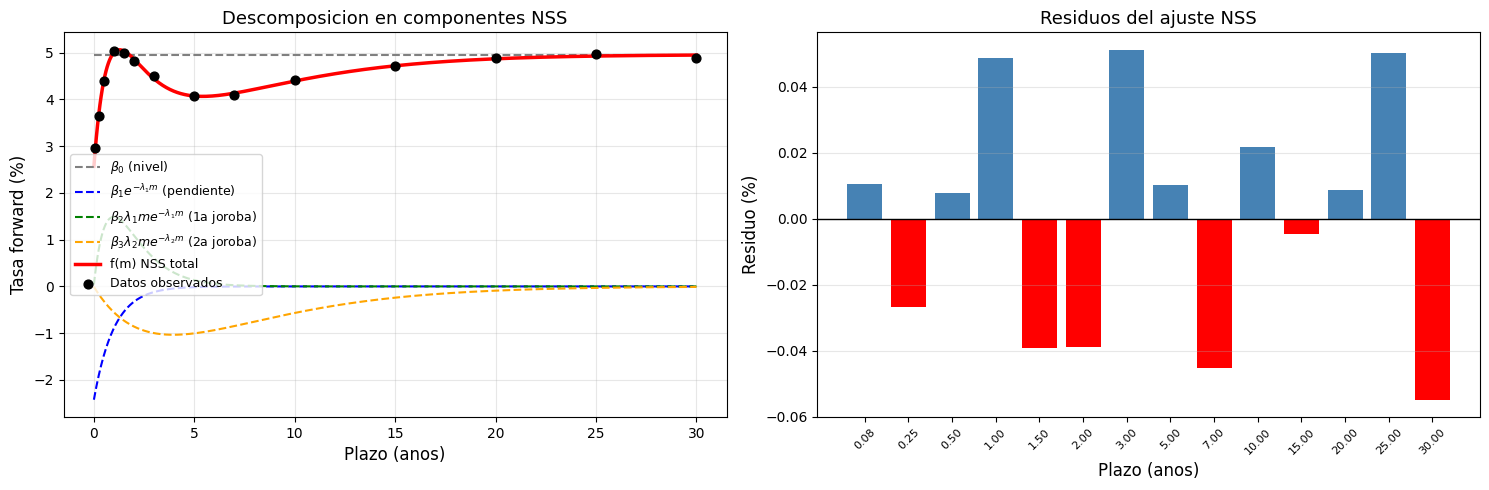

RMSE = 0.035013%


In [8]:
m_cont = np.linspace(0.01, 30, 500)

comp_nivel  = beta0_opt * np.ones_like(m_cont)
comp_slope  = beta1_opt * np.exp(-lam1_opt * m_cont)
comp_curv1  = beta2_opt * lam1_opt * m_cont * np.exp(-lam1_opt * m_cont)
comp_curv2  = beta3_opt * lam2_opt * m_cont * np.exp(-lam2_opt * m_cont)
curva_total = comp_nivel + comp_slope + comp_curv1 + comp_curv2

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(m_cont, comp_nivel,  '--', color='grey',   lw=1.5, label=r'$\beta_0$ (nivel)')
ax.plot(m_cont, comp_slope,  '--', color='blue',   lw=1.5, label=r'$\beta_1 e^{-\lambda_1 m}$ (pendiente)')
ax.plot(m_cont, comp_curv1,  '--', color='green',  lw=1.5, label=r'$\beta_2 \lambda_1 m e^{-\lambda_1 m}$ (1a joroba)')
ax.plot(m_cont, comp_curv2,  '--', color='orange', lw=1.5, label=r'$\beta_3 \lambda_2 m e^{-\lambda_2 m}$ (2a joroba)')
ax.plot(m_cont, curva_total,  'r-',  lw=2.5, label='f(m) NSS total')
ax.scatter(m, y, zorder=5, color='black', s=40, label='Datos observados')
ax.set_xlabel('Plazo (anos)', fontsize=12)
ax.set_ylabel('Tasa forward (%)', fontsize=12)
ax.set_title('Descomposicion en componentes NSS', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

residuos = y - (nss_forward_matrix(m, lam1_opt, lam2_opt) @ beta_opt)
ax2 = axes[1]
ax2.bar(range(len(m)), residuos,
        color=['red' if r < 0 else 'steelblue' for r in residuos])
ax2.axhline(0, color='black', lw=1)
ax2.set_xticks(range(len(m)))
ax2.set_xticklabels([f'{v:.2f}' for v in m], rotation=45, fontsize=8)
ax2.set_xlabel('Plazo (anos)', fontsize=12)
ax2.set_ylabel('Residuo (%)', fontsize=12)
ax2.set_title('Residuos del ajuste NSS', fontsize=13)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print(f'RMSE = {np.sqrt(np.mean(residuos**2)):.6f}%')


## 4. Gráfico interactivo Plotly: una curva NSS con sliders para $\lambda_1$ y $\lambda_2$

El gráfico siguiente permite explorar visualmente el efecto conjunto de los parámetros de decaimiento sobre **una única curva forward NSS**.

- **Slider $\lambda_1$**: controla la posición de la primera joroba.
- **Slider $\lambda_2$**: controla la posición de la segunda joroba.
- En cada cambio, los betas se re-estiman automáticamente por OLS usando el par $(\lambda_1, \lambda_2)$ seleccionado.

In [25]:
# Grid de lambdas para los sliders
lam1_grid = np.round(np.arange(0.1, 2.05, 0.05), 2)
lam2_grid = np.round(np.arange(0.1, 2.05, 0.05), 2)

lam1_init = lam1_grid[np.argmin(np.abs(lam1_grid - lam1_opt))]
lam2_init = lam2_grid[np.argmin(np.abs(lam2_grid - lam2_opt))]

print(f'lam1 inicial: {lam1_init:.2f}  (optimo: {lam1_opt:.4f})')
print(f'lam2 inicial: {lam2_init:.2f}  (optimo: {lam2_opt:.4f})')

m_cont_plot = np.linspace(0.01, 30, 400)

def nss_fit_curve(lam1, lam2, m_obs, y_obs, m_eval):
    if abs(lam1 - lam2) < 0.05:
        lam2 = lam2 + 0.06
    beta, _, _ = fit_betas(m_obs, y_obs, lam1, lam2)
    return (nss_forward_matrix(m_eval, lam1, lam2) @ beta)

print('Pre-calculando curvas para todos los pares (lam1, lam2)...')

# Slider lam1: lam2 fijo en lam2_init
curves_vary_lam1 = {}
for l1 in lam1_grid:
    curves_vary_lam1[l1] = nss_fit_curve(l1, lam2_init, m, y, m_cont_plot).tolist()

# Slider lam2: lam1 fijo en lam1_init
curves_vary_lam2 = {}
for l2 in lam2_grid:
    curves_vary_lam2[l2] = nss_fit_curve(lam1_init, l2, m, y, m_cont_plot).tolist()

print('Pre-calculo completado.')


lam1 inicial: 1.00  (optimo: 1.0033)
lam2 inicial: 0.25  (optimo: 0.2527)
Pre-calculando curvas para todos los pares (lam1, lam2)...
Pre-calculo completado.


In [1]:
# Curva inicial
y_init = nss_fit_curve(lam1_init, lam2_init, m, y, m_cont_plot)

fig = go.Figure()

# Trace 0: datos observados (estatico)
fig.add_trace(go.Scatter(
    x=m, y=y,
    mode='markers',
    name='Datos observados',
    marker=dict(size=9, color='rgba(31,119,180,0.8)', symbol='circle'),
))

# Trace 1: unica curva NSS (la actualizan ambos sliders)
fig.add_trace(go.Scatter(
    x=m_cont_plot, y=y_init,
    mode='lines',
    name='f(m) NSS interactiva',
    line=dict(color='red', width=3),
))

# Steps slider lambda1
steps_lam1 = []
for l1 in lam1_grid:
    steps_lam1.append(dict(
        method='restyle',
        args=[{'y': [curves_vary_lam1[l1]]}, [1]],
        label=f'{l1:.2f}',
    ))

# Steps slider lambda2
steps_lam2 = []
for l2 in lam2_grid:
    steps_lam2.append(dict(
        method='restyle',
        args=[{'y': [curves_vary_lam2[l2]]}, [1]],
        label=f'{l2:.2f}',
    ))

idx_lam1_init = int(np.argmin(np.abs(lam1_grid - lam1_init)))
idx_lam2_init = int(np.argmin(np.abs(lam2_grid - lam2_init)))

fig.update_layout(
    title=dict(
        text='Nelson-Siegel-Svensson — Sliders interactivos para lambda1 y lambda2',
        font=dict(size=15),
    ),
    xaxis_title='Plazo (anos)',
    yaxis_title='Tasa forward (%)',
    template='plotly_white',
    legend=dict(x=0.8, y=0.04),
    height=650,
    margin=dict(b=200),
    sliders=[
        dict(
            active=idx_lam1_init,
            currentvalue=dict(
                prefix='lambda1 = 1/tau1 = ',
                suffix='  =>  mueve la curva NSS',
                font=dict(size=12),
            ),
            pad=dict(t=15, b=5, l=10, r=10),
            len=0.92,
            x=0.04,
            y=-0.14,
            steps=steps_lam1,
        ),
        dict(
            active=idx_lam2_init,
            currentvalue=dict(
                prefix='lambda2 = 1/tau2 = ',
                suffix='  =>  mueve la curva NSS',
                font=dict(size=12),
            ),
            pad=dict(t=15, b=5, l=10, r=10),
            len=0.92,
            x=0.04,
            y=-0.42,
            steps=steps_lam2,
        ),
    ],
)

fig.show()


NameError: name 'nss_fit_curve' is not defined

## 5. Comparación NS vs NSS — ¿cuándo importa el cuarto término?

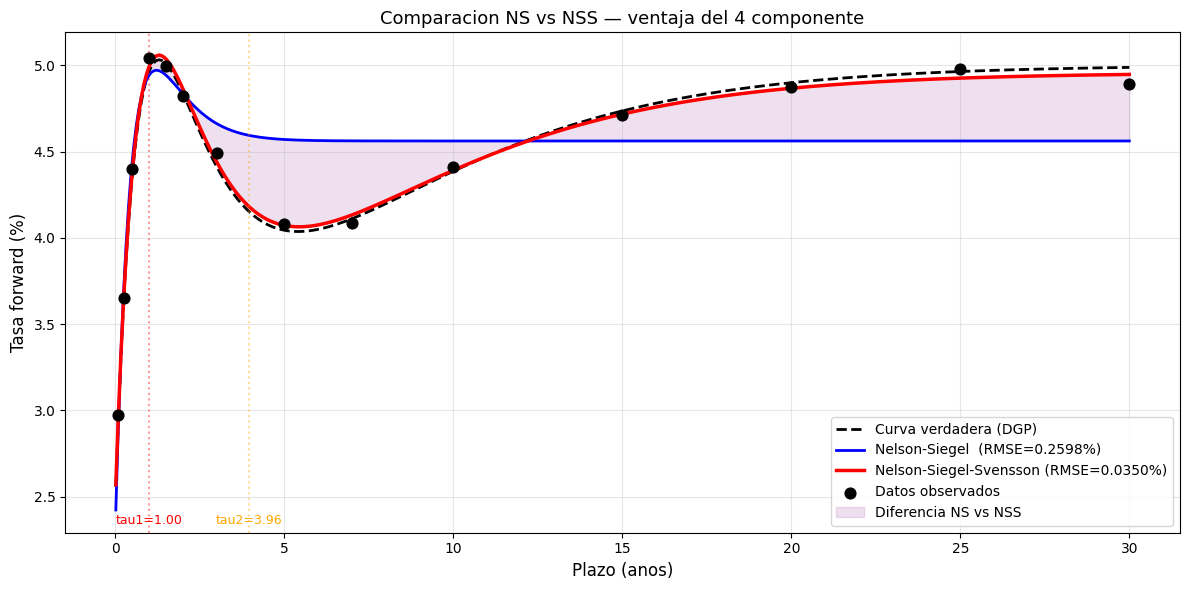

RMSE NS:  0.259753%
RMSE NSS: 0.035013%
Mejora de RMSE al pasar de NS a NSS: 86.5%


In [27]:
# Ajuste NS clasico
def ns_forward_matrix(m, lam):
    m = np.asarray(m, dtype=float)
    return np.column_stack([
        np.ones_like(m),
        np.exp(-lam * m),
        lam * m * np.exp(-lam * m),
    ])

def ns_sse(lam, m, y):
    if lam <= 0: return 1e10
    X = ns_forward_matrix(m, lam)
    beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    return np.sum((y - X @ beta)**2)

res_ns = minimize_scalar(ns_sse, bounds=(0.01, 5.0), method='bounded', args=(m, y))
lam_ns_opt = res_ns.x
X_ns = ns_forward_matrix(m, lam_ns_opt)
beta_ns, _, _, _ = np.linalg.lstsq(X_ns, y, rcond=None)

rmse_ns  = np.sqrt(np.mean((y - X_ns @ beta_ns)**2))
rmse_nss = np.sqrt(np.mean((y - nss_forward_matrix(m, lam1_opt, lam2_opt) @ beta_opt)**2))

y_ns_cont   = ns_forward_matrix(m_cont_plot, lam_ns_opt) @ beta_ns
y_nss_cont  = nss_forward_matrix(m_cont_plot, lam1_opt, lam2_opt) @ beta_opt
y_true_cont = nss_forward(m_cont_plot, beta0_true, beta1_true, beta2_true,
                           beta3_true, tau1_true, tau2_true)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(m_cont_plot, y_true_cont, 'k--', lw=2, label='Curva verdadera (DGP)')
ax.plot(m_cont_plot, y_ns_cont,   'b-',  lw=2,   label=f'Nelson-Siegel  (RMSE={rmse_ns:.4f}%)')
ax.plot(m_cont_plot, y_nss_cont,  'r-',  lw=2.5, label=f'Nelson-Siegel-Svensson (RMSE={rmse_nss:.4f}%)')
ax.scatter(m, y, color='black', s=60, zorder=5, label='Datos observados')
ax.fill_between(m_cont_plot, y_ns_cont, y_nss_cont, alpha=0.12, color='purple',
                label='Diferencia NS vs NSS')

ax.axvline(x=tau1_opt, color='red',    alpha=0.4, ls=':', lw=1.5)
ax.axvline(x=tau2_opt, color='orange', alpha=0.4, ls=':', lw=1.5)
ylim = ax.get_ylim()
ax.text(tau1_opt, ylim[0]+0.05, f'tau1={tau1_opt:.2f}', color='red',    fontsize=9, ha='center')
ax.text(tau2_opt, ylim[0]+0.05, f'tau2={tau2_opt:.2f}', color='orange', fontsize=9, ha='center')

ax.set_xlabel('Plazo (anos)', fontsize=12)
ax.set_ylabel('Tasa forward (%)', fontsize=12)
ax.set_title('Comparacion NS vs NSS — ventaja del 4 componente', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'RMSE NS:  {rmse_ns:.6f}%')
print(f'RMSE NSS: {rmse_nss:.6f}%')
mejora = 100*(rmse_ns-rmse_nss)/rmse_ns
print(f'Mejora de RMSE al pasar de NS a NSS: {mejora:.1f}%')


## 6. Ejercicio práctico — Tu turno

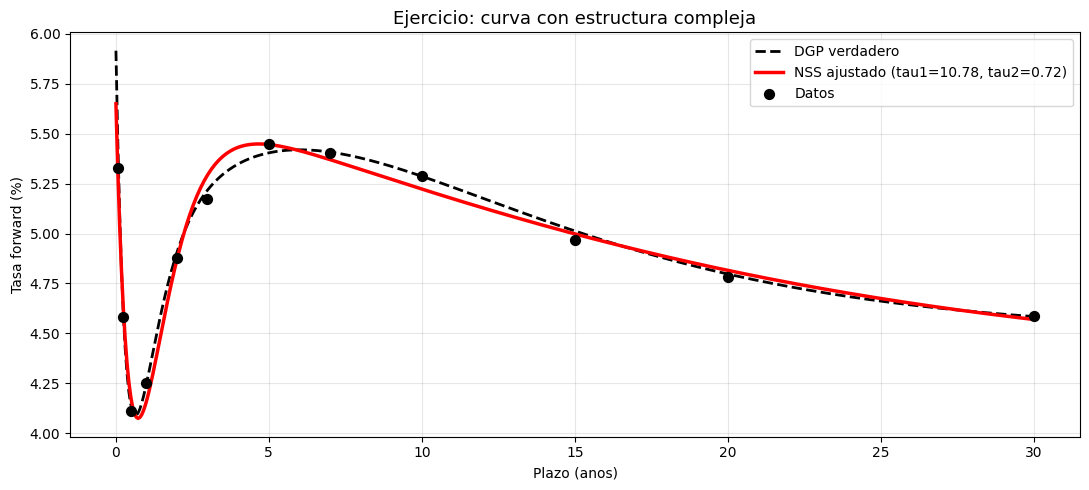

Modifica b0, b1, b2, b3, t1, t2 para ver diferentes formas de curva.


In [12]:
# EJERCICIO 1: Curva invertida con segunda joroba
# Modifica los parametros y observa como NSS se adapta

m_ej = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 15, 20, 30])

# Prueba con distintos valores
b0, b1, b2, b3 = 4.5,  1.5, -3.0, 2.5
t1, t2         = 0.5,  6.0

f_ej = nss_forward(m_ej, b0, b1, b2, b3, t1, t2)
y_ej = f_ej + np.random.normal(0, 0.03, len(m_ej))

# Ajuste automatico
best_sse_ej, best_pair_ej = np.inf, (1.0, 0.2)
for l1 in np.linspace(0.1, 4.0, 20):
    for l2 in np.linspace(0.1, 4.0, 20):
        if abs(l1 - l2) > 0.05:
            sse = nss_sse([l1, l2], m_ej, y_ej)
            if sse < best_sse_ej:
                best_sse_ej, best_pair_ej = sse, (l1, l2)

result_ej = minimize(nss_sse, x0=list(best_pair_ej), args=(m_ej, y_ej, True),
                     method='Nelder-Mead',
                     options={'xatol':1e-8,'fatol':1e-10,'maxiter':50000})
l1_ej, l2_ej  = result_ej.x
beta_ej, _, _ = fit_betas(m_ej, y_ej, l1_ej, l2_ej)

m_c = np.linspace(0.01, 30, 500)
f_ajuste_ej = nss_forward_matrix(m_c, l1_ej, l2_ej) @ beta_ej
f_true_ej   = nss_forward(m_c, b0, b1, b2, b3, t1, t2)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(m_c, f_true_ej,   'k--', lw=2, label='DGP verdadero')
ax.plot(m_c, f_ajuste_ej, 'r-',  lw=2.5,
        label=f'NSS ajustado (tau1={1/l1_ej:.2f}, tau2={1/l2_ej:.2f})')
ax.scatter(m_ej, y_ej, s=50, color='black', zorder=5, label='Datos')
ax.set_xlabel('Plazo (anos)'); ax.set_ylabel('Tasa forward (%)')
ax.set_title('Ejercicio: curva con estructura compleja', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('Modifica b0, b1, b2, b3, t1, t2 para ver diferentes formas de curva.')


Calculando superficie SSE...


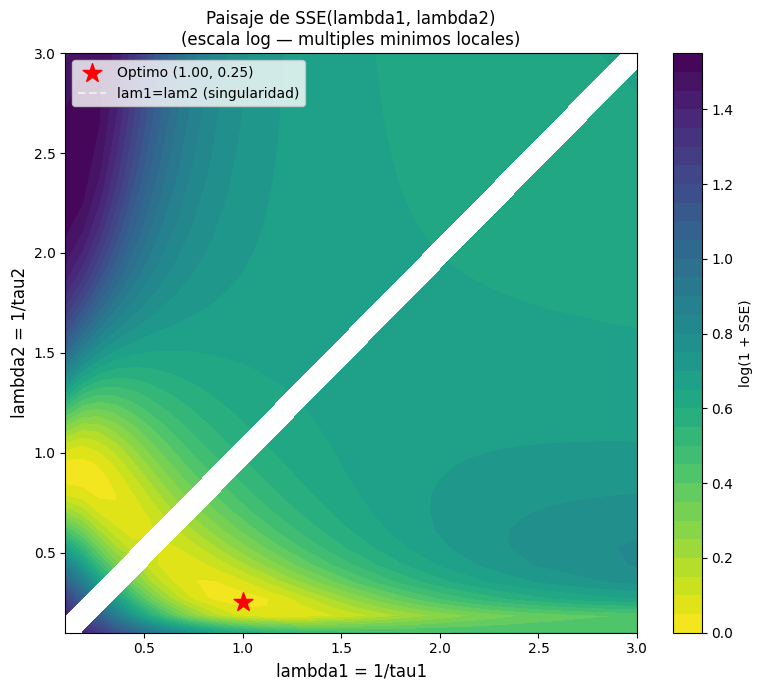

Nota: la diagonal blanca = singularidad (lam1 aprox lam2).
Observa los multiples minimos locales => necesitamos grid search.


In [13]:
# EJERCICIO 2: Superficie de SSE en el espacio (lam1, lam2)
print('Calculando superficie SSE...')

lam_range   = np.linspace(0.1, 3.0, 35)
SSE_surface = np.full((len(lam_range), len(lam_range)), np.nan)

for i, l1 in enumerate(lam_range):
    for j, l2 in enumerate(lam_range):
        if abs(l1 - l2) > 0.05:
            SSE_surface[i, j] = nss_sse([l1, l2], m, y)

SSE_log = np.log1p(SSE_surface)

fig, ax = plt.subplots(figsize=(8, 7))
cf = ax.contourf(lam_range, lam_range, SSE_log.T, levels=30, cmap='viridis_r')
plt.colorbar(cf, ax=ax, label='log(1 + SSE)')
ax.scatter([lam1_opt], [lam2_opt], color='red', s=200, zorder=5,
           marker='*', label=f'Optimo ({lam1_opt:.2f}, {lam2_opt:.2f})')
ax.plot([0.1, 3.0], [0.1, 3.0], 'w--', lw=1.5, alpha=0.6, label='lam1=lam2 (singularidad)')
ax.set_xlabel('lambda1 = 1/tau1', fontsize=12)
ax.set_ylabel('lambda2 = 1/tau2', fontsize=12)
ax.set_title('Paisaje de SSE(lambda1, lambda2)\n(escala log — multiples minimos locales)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
print('Nota: la diagonal blanca = singularidad (lam1 aprox lam2).')
print('Observa los multiples minimos locales => necesitamos grid search.')


## 7. Resumen y conclusiones

### Lo que aprendimos

1. **Por qué NSS**: el modelo Nelson-Siegel solo puede generar una joroba. Cuando la curva de mercado tiene dos inflexiones (situación frecuente en mercados emergentes o transiciones de política), NS falla sistemáticamente.

2. **La extensión de Svensson**: añade un cuarto término $\beta_3 \lambda_2 m e^{-\lambda_2 m}$ con su propio decaimiento $\lambda_2$. Son solo 2 parámetros adicionales pero cambian cualitativamente las formas de curva alcanzables.

3. **Estrategia de estimación**:
   - Los betas son lineales dado $(\lambda_1, \lambda_2)$ → OLS exacto
   - Los lambdas son no lineales → grid search + optimización local
   - El paisaje SSE tiene múltiples mínimos locales → siempre usar múltiples puntos iniciales

4. **Los sliders $\lambda_1$ y $\lambda_2$** ilustran que:
   - $\lambda_1$ grande $\Rightarrow$ primera joroba en el corto plazo ($\tau_1 = 1/\lambda_1$ pequeño)
   - $\lambda_2$ grande $\Rightarrow$ segunda joroba en el corto plazo ($\tau_2 = 1/\lambda_2$ pequeño)
   - $\lambda_1 \neq \lambda_2$ es condición necesaria de identificación

### Lecturas recomendadas

- **Nelson & Siegel (1987)**: *Parsimonious Modeling of Yield Curves*, Journal of Business.
- **Svensson (1994)**: *Estimating and Interpreting Forward Interest Rates*, NBER WP 4871.
- **BIS (2005)**: *Zero-coupon yield curves: technical documentation*, BIS Papers No 25.
- **Diebold & Li (2006)**: *Forecasting the term structure of government bond yields*, Journal of Econometrics.

---
*Notebook elaborado como extensión del notebook Nelson-Siegel desde cero (tasas forward).*
